# Lineární regrese – Cvičení 2 (Linear Regression – Exercise 2)
**Případová studie:** Automatizace oceňování diamantů pro klenotníka (`diamonds.csv`)

---

### Zadání / Assignment:
Představte si, že jste datový vědec a váš přítel je klenotník. Do jeho klenotnictví chodí obrovské množství zákazníků, kteří přinášejí diamanty k prodeji. Zájemců je tolik, že přítel není schopen kameny z časových důvodů oceňovat. Jako expert na data nabídnete automatizaci oceňování pomocí strojového učení. Požádáte ho o historická data, ze kterých vycházel při dřívějších odhadech. Vaším úkolem je data analyzovat, vyčistit a postavit lineární regresní model, který určí cenu diamantu na základě jeho vlastností.

**Popis přijatých dat:**
- `carat`: fyzická hmotnost diamantu v karátech (1 karát = 0,20 g).
- `cut`: kvalita brusu (Fair, Good, Very Good, Premium, Ideal).
- `color`: barva diamantu od J (nejhorší / nažloutlá) po D (nejlepší / bezbarvá).
- `clarity`: čistota diamantu (I1 nejhorší, SI2, SI1, VS2, VS1, VVS2, VVS1, IF nejlepší bez vnitřních inkluzí).
- `depth`: celková hloubka v procentech $= z / 	ext{mean}(x, y)$.
- `table`: šířka horní plošky diamantu vzhledem k nejširšímu bodu.
- `price`: cena diamantu v USD ($326 - $18,823).
- `x`: délka v mm.
- `y`: šířka v mm.
- `z`: výška/hloubka v mm.

**Kroky zpracování:**
1. Přeneste datový soubor `diamonds.csv` do běhového prostředí.
2. Importujte všechny potřebné metody z knihoven (`pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`).
3. Načtěte data do Pandas DataFrame a uložte do proměnné `diamonds_df`.
4. Zobrazte prvních cca 15 záznamů pro seznámení se s daty.
5. Odstraňte nepotřebné sloupce z datové sady (`Unnamed: 0`).
6. Ověřte přítomnost chybějících hodnot (missing values).
7. Pomocí vhodného nástroje knihovny seaborn (`sns.pairplot`) zkontrolujte vztahy mezi proměnnými a distribuce na jednom grafu.
8. Vygenerujte a vizualizujte korelační matici. Vyřaďte proměnné s nízkým korelačním koeficientem. Ověřte linearitu zbývajících proměnných na scatter plotech vůči ceně (`price`).
9. Pomocí scatter plotů zkontrolujte odlehlé hodnoty (outliers) a vybranou metodou je odstraňte (nulové rozměry, překlepy, extrémy).
10. Rozdělte data na trénovací a testovací sadu (Train/Test Split).
11. Definujte a natrénujte model `LinearRegression` na trénovacích datech a predikujte testovací data. Vyhodnoťte metriky ($R^2$, RMSE, MAE).
12. Uložte připravený dataset do souboru `.csv` (`diamonds_preprocessed.csv`).
13. **Vlastní analýza a moderní rozšíření (09/2026):** Multikolinearita a fyzika diamantu, vliv 4C parametrů, nelineární mocninný zákon (Log-Log regrese) a srovnání se State-of-the-Art gradient boostingem.

## Krok 1: Import knihoven a konfigurace prostředí

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

# Nastavení vizuálního stylu
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

base_dir = Path('.')
data_dir = base_dir / 'data'
plots_dir = base_dir / 'plots'
data_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
print('Knihovny úspěšně načteny.')

Knihovny úspěšně načteny.


## Krok 2: Načtení datové sady klenotníka (`diamonds_df`)

In [2]:
raw_csv_path = data_dir / 'diamonds.csv'
if not raw_csv_path.exists():
    fallback_path = Path('../data/MAL_downloadable materials_session 1/Day 1/diamonds.csv')
    if fallback_path.exists():
        import shutil
        shutil.copy(fallback_path, raw_csv_path)

diamonds_df = pd.read_csv(raw_csv_path)
print(f'Rozměry načteného datasetu: {diamonds_df.shape[0]} řádků, {diamonds_df.shape[1]} sloupců.')

Rozměry načteného datasetu: 53940 řádků, 11 sloupců.


## Krok 3: Náhled prvních 15 záznamů

In [3]:
diamonds_df.head(15)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


## Krok 4: Odstranění nepotřebných sloupců (`Unnamed: 0`)

In [4]:
if 'Unnamed: 0' in diamonds_df.columns:
    diamonds_df = diamonds_df.drop(columns=['Unnamed: 0'])
    print("Sloupec 'Unnamed: 0' byl odstraněn.")

print('Aktuální sloupce:', list(diamonds_df.columns))

Sloupec 'Unnamed: 0' byl odstraněn.
Aktuální sloupce: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


## Krok 5: Ověření přítomnosti chybějících hodnot

In [5]:
missing = diamonds_df.isnull().sum()
print('Počet chybějících hodnot v jednotlivých sloupcích:')
print(missing[missing > 0] if missing.sum() > 0 else '0 chybějících hodnot – dataset je kompletní.')

Počet chybějících hodnot v jednotlivých sloupcích:
0 chybějících hodnot – dataset je kompletní.


## Krok 6: Vizualizace vztahů a distribucí pomocí `sns.pairplot`
Použijeme reprezentativní vzorek 1 500 diamantů pro přehlednou a svižnou vizualizaci vazeb mezi numerickými proměnnými.

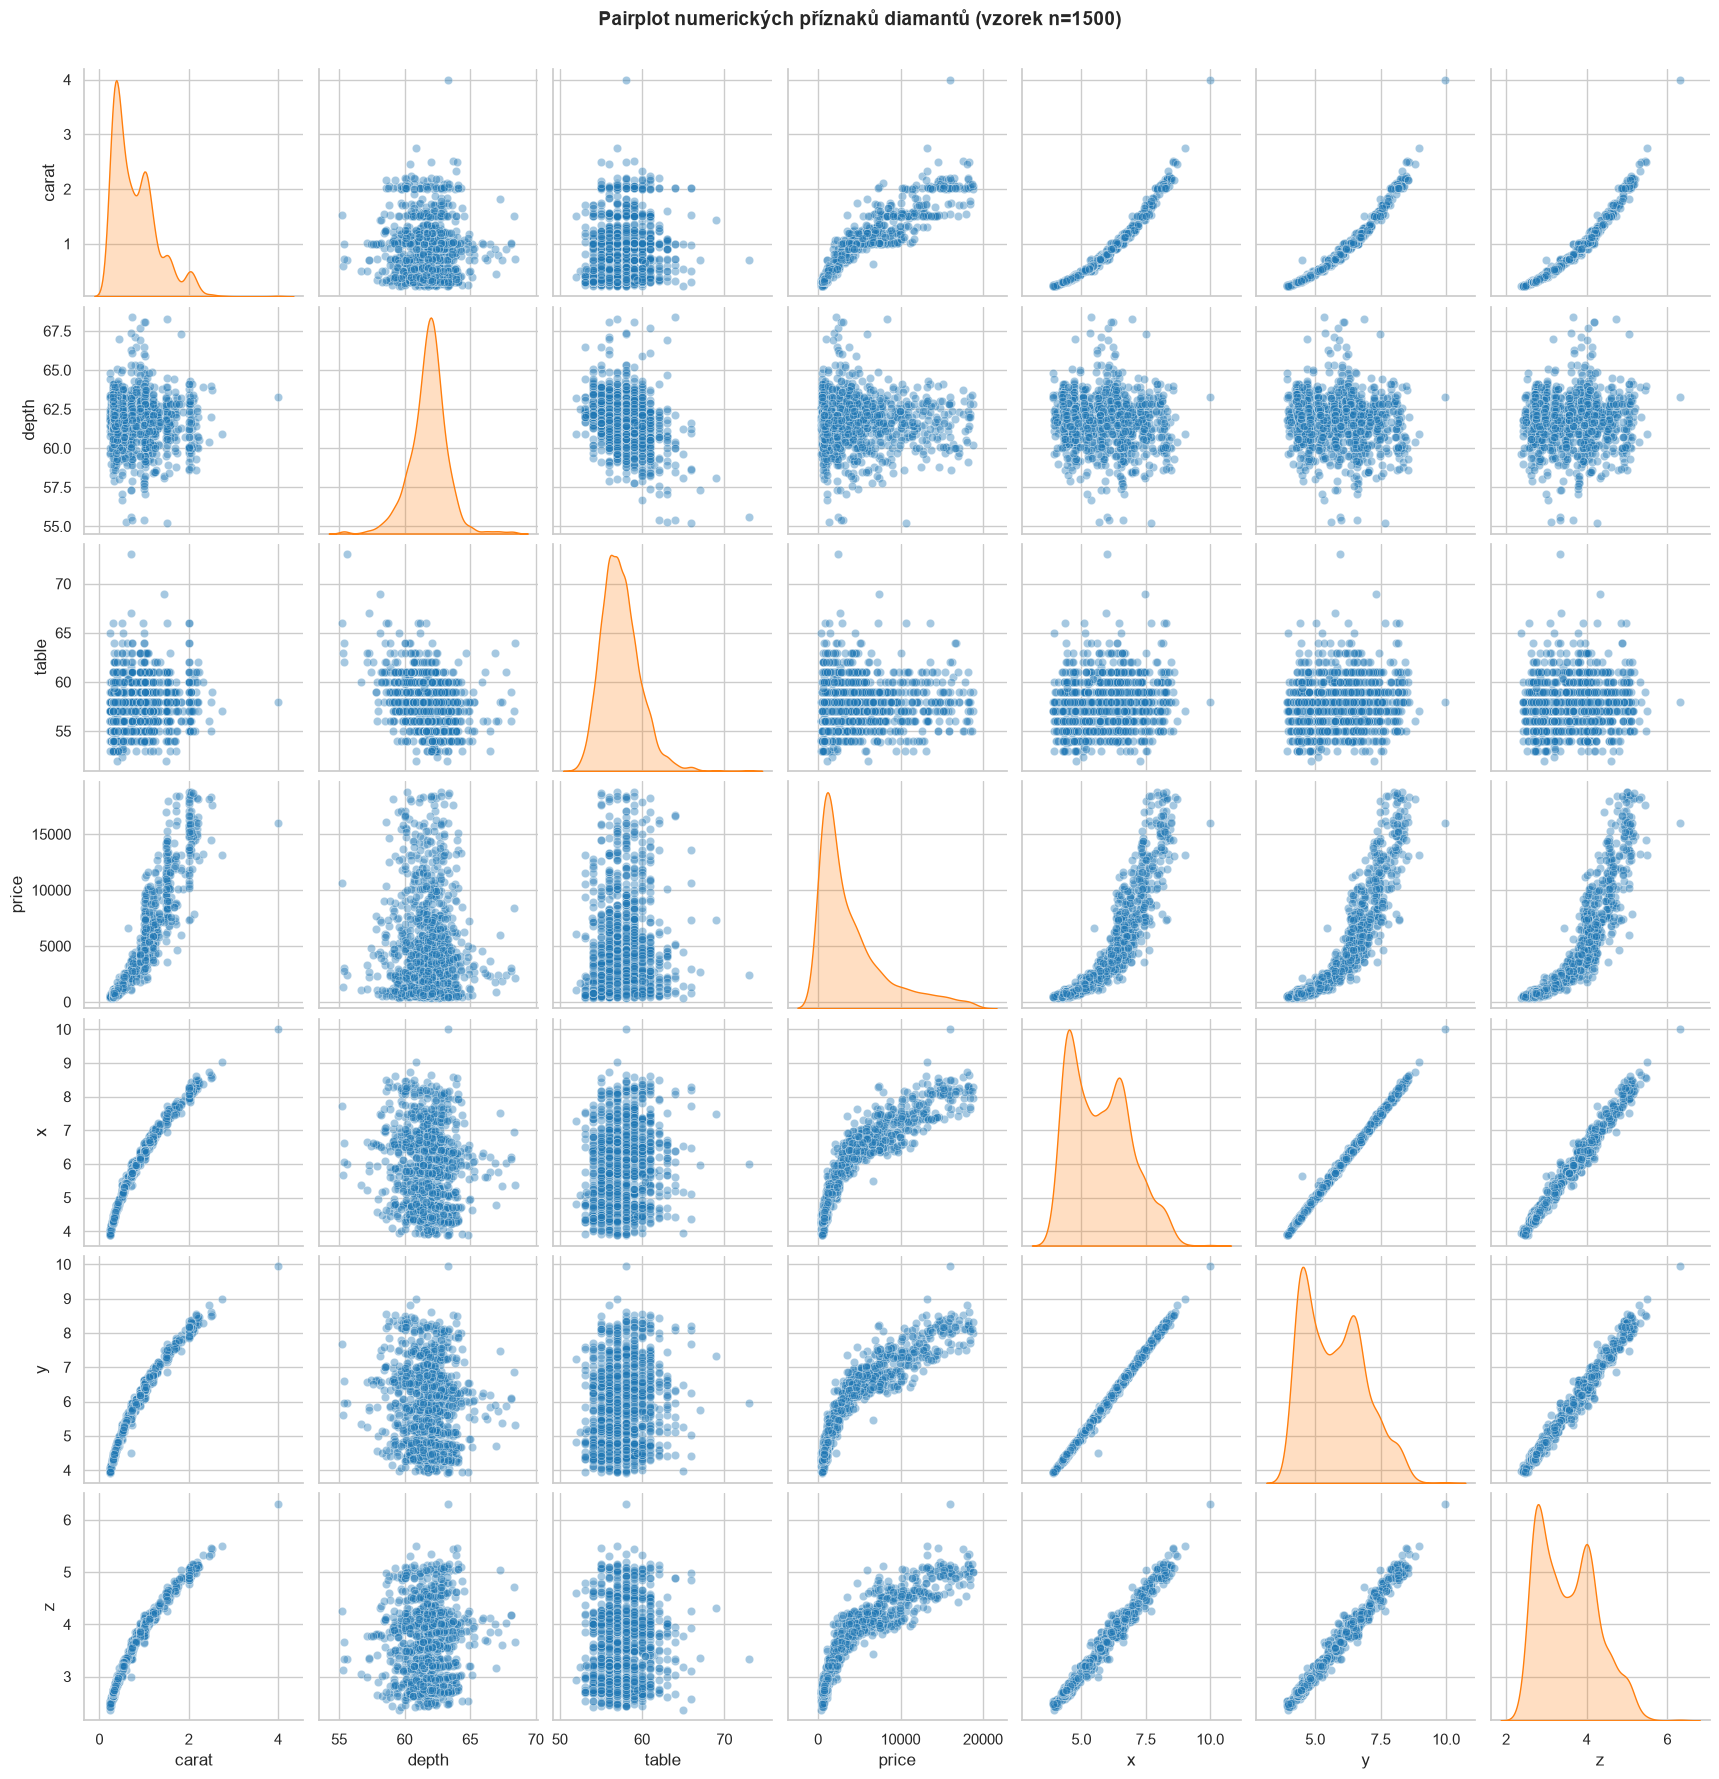

In [6]:
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
sample_df = diamonds_df[numeric_cols].sample(n=1500, random_state=42)

pairplot_fig = sns.pairplot(
    sample_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 'color': '#1f77b4'},
    diag_kws={'color': '#ff7f0e'}
)
pairplot_fig.fig.suptitle('Pairplot numerických příznaků diamantů (vzorek n=1500)', y=1.02, fontsize=14, fontweight='bold')
plt.savefig(plots_dir / '05_diamonds_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Krok 7: Korelační matice a vyřazení nízko korelujících proměnných
Zkoumáme Pearsonovy korelační koeficienty s cílovou cenou `price`.

Korelace s cenou (price):
price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64


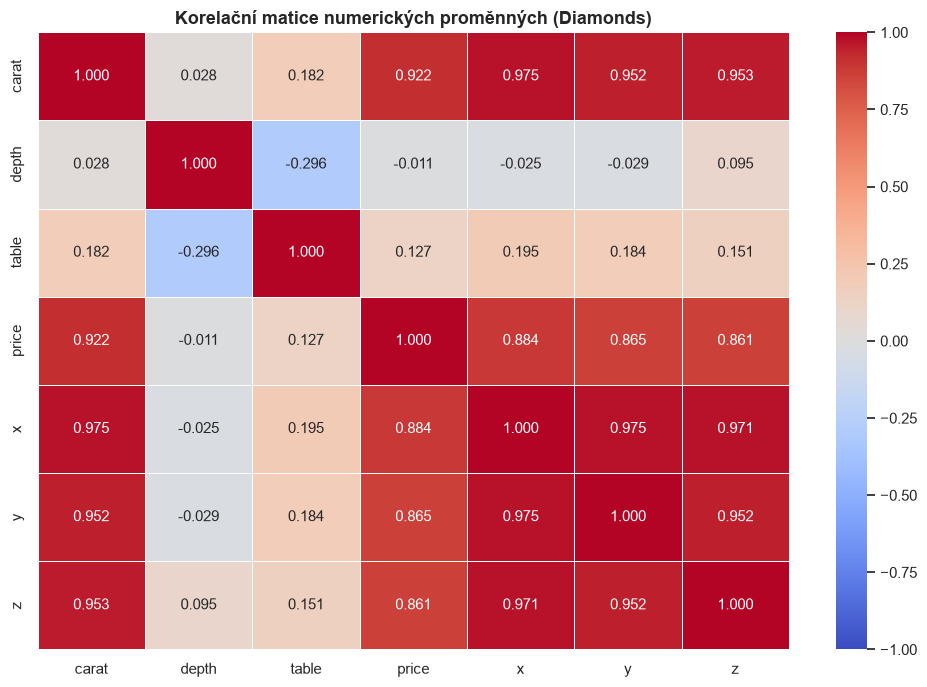

In [7]:
corr_matrix = diamonds_df[numeric_cols].corr()
price_corr = corr_matrix['price'].sort_values(ascending=False)
print('Korelace s cenou (price):')
print(price_corr)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Korelační matice numerických proměnných (Diamonds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(plots_dir / '06_diamonds_correlation_matrix.png', dpi=300)
plt.show()

### Vyřazení slabých příznaků a ověření linearity
- Proměnné `depth` ($r = -0.011$) a `table` ($r = 0.127$) vykazují téměř nulovou korelaci s cenou diamantu $\rightarrow$ vyřazujeme je.
- Silně korelující proměnné s cenou: `carat` ($r = 0.922$), `x` ($r = 0.884$), `y` ($r = 0.865$), `z` ($r = 0.861$).

Vyřazené slabé proměnné: ['depth', 'table']
Ponechané silně korelující proměnné: ['carat', 'x', 'y', 'z']


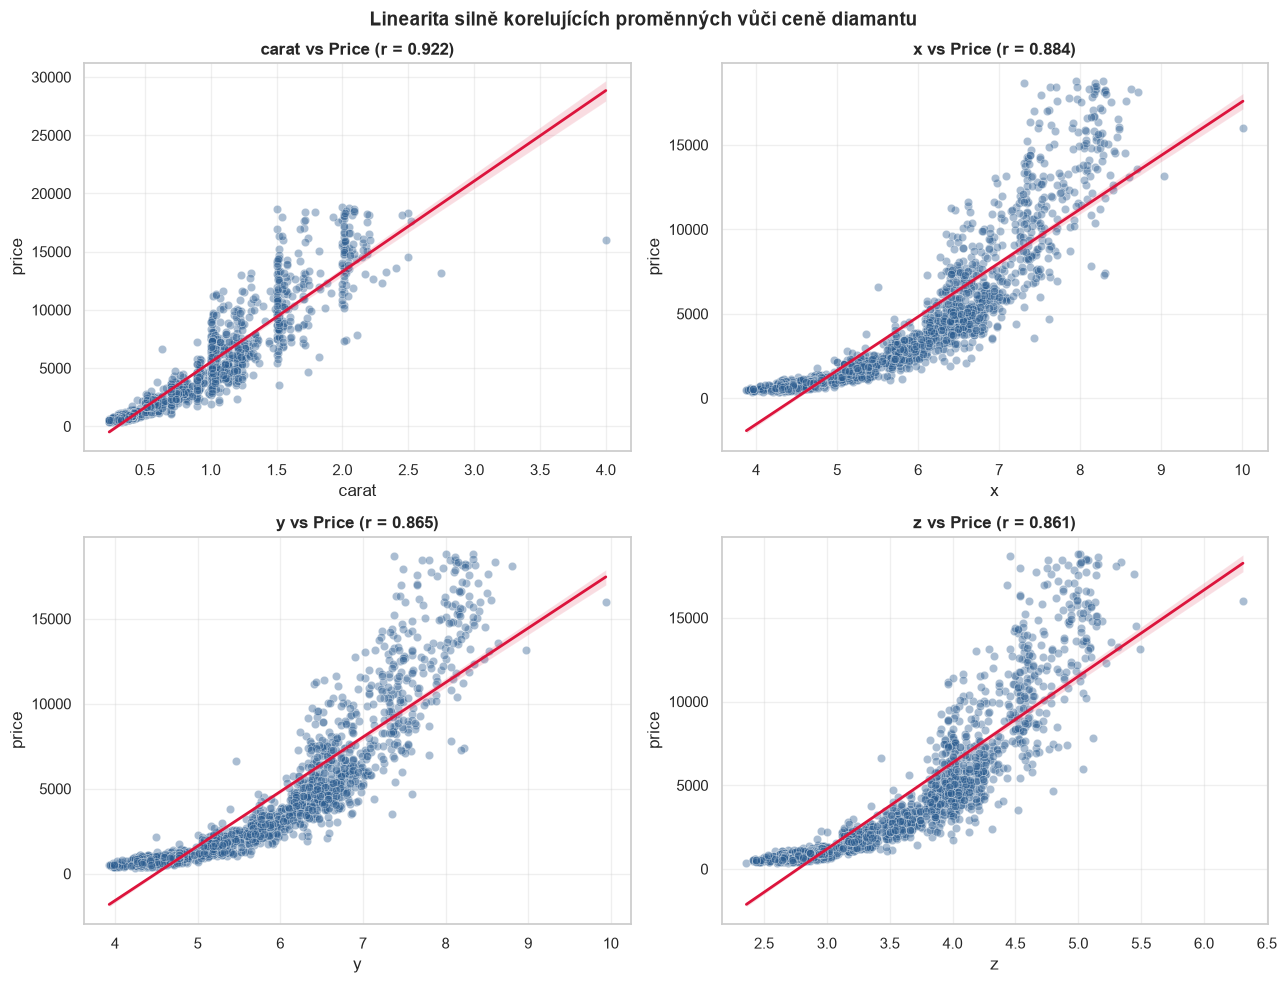

In [8]:
low_corr_cols = ['depth', 'table']
high_corr_cols = ['carat', 'x', 'y', 'z']
print(f'Vyřazené slabé proměnné: {low_corr_cols}')
print(f'Ponechané silně korelující proměnné: {high_corr_cols}')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, feat in zip(axes.flatten(), high_corr_cols):
    sns.scatterplot(data=diamonds_df.sample(2000, random_state=42), x=feat, y='price', alpha=0.4, ax=ax, color='#2b5c8f')
    sns.regplot(data=diamonds_df.sample(2000, random_state=42), x=feat, y='price', scatter=False, ax=ax, color='crimson', line_kws={'linewidth': 2})
    ax.set_title(f'{feat} vs Price (r = {corr_matrix.loc[feat, "price"]:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Linearita silně korelujících proměnných vůči ceně diamantu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(plots_dir / '07_diamonds_scatter_linearity.png', dpi=300)
plt.show()

## Krok 8: Detekce a odstranění odlehlých hodnot (Outliers)
Hledáme zjevné chyby a anomálie v datech:
1. **Fyzikálně nemožné hodnoty:** Rozměry $x=0$, $y=0$ nebo $z=0$ (3D diamant nemůže mít nulový rozměr).
2. **Extrémní překlepy:** Hodnoty šířky $y > 20$ mm nebo hloubky $z > 20$ mm (např. 58.9 mm a 31.8 mm – chybně posunutá desetinná čárka).
3. **Extrémní investiční kameny:** Diamanty nad 3.5 karátu.

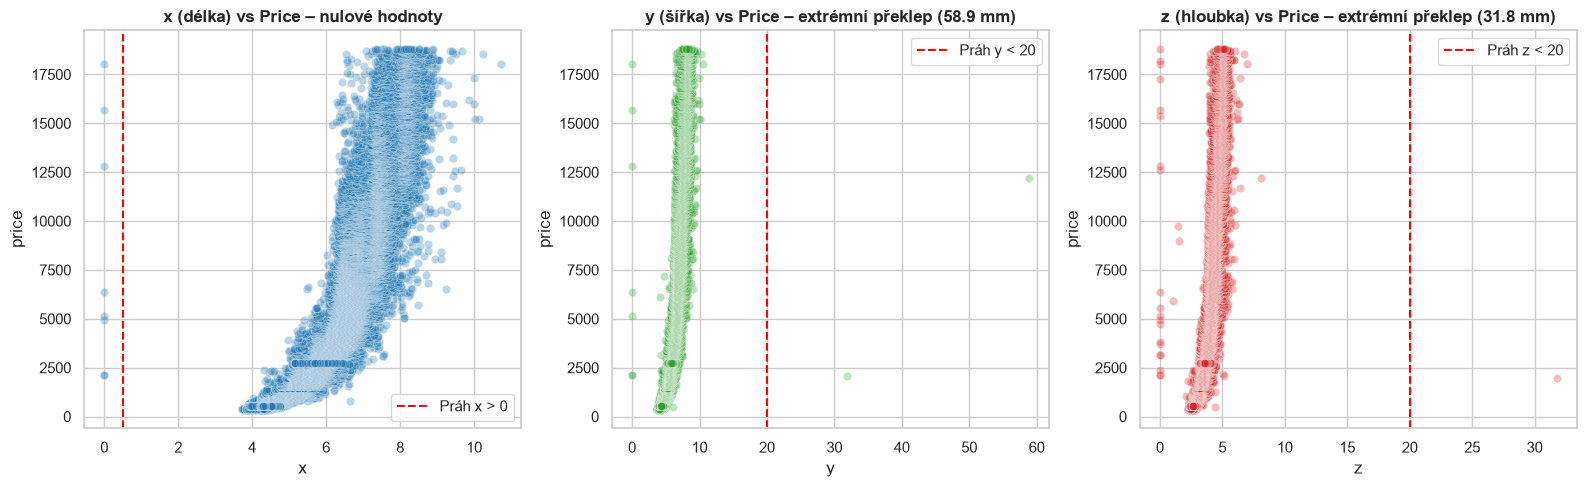

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=diamonds_df, x='x', y='price', alpha=0.3, ax=axes[0], color='#1f77b4')
axes[0].set_title('x (délka) vs Price – nulové hodnoty', fontweight='bold')
axes[0].axvline(0.5, color='red', linestyle='--', label='Práh x > 0')
axes[0].legend()

sns.scatterplot(data=diamonds_df, x='y', y='price', alpha=0.3, ax=axes[1], color='#2ca02c')
axes[1].set_title('y (šířka) vs Price – extrémní překlep (58.9 mm)', fontweight='bold')
axes[1].axvline(20, color='red', linestyle='--', label='Práh y < 20')
axes[1].legend()

sns.scatterplot(data=diamonds_df, x='z', y='price', alpha=0.3, ax=axes[2], color='#d62728')
axes[2].set_title('z (hloubka) vs Price – extrémní překlep (31.8 mm)', fontweight='bold')
axes[2].axvline(20, color='red', linestyle='--', label='Práh z < 20')
axes[2].legend()

plt.tight_layout()
plt.savefig(plots_dir / '08_diamonds_outliers_detection.png', dpi=300)
plt.show()

### Odfiltrování odlehlých hodnot

In [10]:
clean_diamonds_df = diamonds_df[
    (diamonds_df['x'] > 0) &
    (diamonds_df['y'] > 0) &
    (diamonds_df['z'] > 0) &
    (diamonds_df['y'] < 20) &
    (diamonds_df['z'] < 20) &
    (diamonds_df['carat'] <= 3.5)
].copy()

dropped_count = len(diamonds_df) - len(clean_diamonds_df)
print(f'Původní počet řádků: {len(diamonds_df)}')
print(f'Odstraněno anomálií: {dropped_count} ({dropped_count / len(diamonds_df) * 100:.2f} %)')
print(f'Čistý počet řádků:    {len(clean_diamonds_df)}')

Původní počet řádků: 53940
Odstraněno anomálií: 32 (0.06 %)
Čistý počet řádků:    53908


## Krok 9: Rozdělení dat na trénovací a testovací sadu (Train/Test Split)

In [11]:
X_simple = clean_diamonds_df[high_corr_cols]
y = clean_diamonds_df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

X_train: (43126, 4), y_train: (43126,)
X_test:  (10782, 4), y_test:  (10782,)


## Krok 10: Trénování modelu `LinearRegression` a evaluace

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_test = lin_reg.predict(X_test)
r2_test = lin_reg.score(X_test, y_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f'Model: LinearRegression na příznacích {high_corr_cols}')
print(f'Testovací R2 skóre: {r2_test:.4f}')
print(f'Testovací RMSE:     ${rmse_test:,.2f}')
print(f'Testovací MAE:      ${mae_test:,.2f}')

print('\nKoeficienty modelu:')
for feat, coef in zip(high_corr_cols, lin_reg.coef_):
    print(f'  - {feat:10s}: {coef:12.2f}')
print(f'  - Intercept : {lin_reg.intercept_:12.2f}')

Model: LinearRegression na příznacích ['carat', 'x', 'y', 'z']
Testovací R2 skóre: 0.8576
Testovací RMSE:     $1,470.79
Testovací MAE:      $880.18

Koeficienty modelu:
  - carat     :     11380.26
  - x         :     -3675.65
  - y         :      3761.86
  - z         :     -2602.72
  - Intercept :      3567.40


## Krok 11: Uložení připraveného datasetu do CSV

In [13]:
prep_df = clean_diamonds_df.copy()

# Ordinální kódování 4C parametrů dle gemologické stupnice
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_order = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

prep_df['cut'] = prep_df['cut'].map(cut_order)
prep_df['color'] = prep_df['color'].map(color_order)
prep_df['clarity'] = prep_df['clarity'].map(clarity_order)

output_csv = data_dir / 'diamonds_preprocessed.csv'
prep_df.to_csv(output_csv, index=False)
print(f'Vyčištěný a zakódovaný dataset byl uložen do: {output_csv}')

Vyčištěný a zakódovaný dataset byl uložen do: data\diamonds_preprocessed.csv


## Krok 12: Vlastní analýza a moderní ML rozšíření (Stav k 09/2026)

### A. Multikolinearita a fyzikální paradox vah
Všimněte si vah modelu: `carat` má koeficient $+11380$, ale délka `x` má **$-3675$** a hloubka `z` má **$-2602$**!  
Znamená to snad, že větší diamant má nižší cenu? **Samozřejmě ne.** Jedná se o učebnicový projev **extrémní multikolinearity**:
Hmotnost diamantu v karátech je fyzikálně svázána s jeho objemem ($V \approx x \cdot y \cdot z$). Korelace mezi `carat` a odhadnutým objemem je **0.9989**!

In [14]:
v_est = clean_diamonds_df['x'] * clean_diamonds_df['y'] * clean_diamonds_df['z']
print(f'Korelace mezi hmotností (carat) a objemem (x*y*z): {np.corrcoef(clean_diamonds_df["carat"], v_est)[0, 1]:.4f}')

Korelace mezi hmotností (carat) a objemem (x*y*z): 0.9989


### B. Zahrnutí gemologických 4C parametrů (Carat, Cut, Color, Clarity)
Klenotník se nikdy nerozhoduje jen podle karátů. Zahrnutí kvality brusu, barvy a čistoty diamantu.

In [15]:
X_4c = prep_df[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']]
X_4c_tr, X_4c_te, y_4c_tr, y_4c_te = train_test_split(X_4c, y, test_size=0.2, random_state=42)

lin_reg_4c = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lin_reg_4c.fit(X_4c_tr, y_4c_tr)
print(f'R2 skóre s 4C parametry: {lin_reg_4c.score(X_4c_te, y_4c_te):.4f} (nárůst z {r2_test:.4f})')
print(f'MAE s 4C parametry:      ${mean_absolute_error(y_4c_te, lin_reg_4c.predict(X_4c_te)):,.2f}')

R2 skóre s 4C parametry: 0.9095 (nárůst z 0.8576)
MAE s 4C parametry:      $784.78


### C. Nelineární mocninný zákon: Log-Log model cenotvorby drahokamů
Cena diamantů roste s karáty superlineárně (mocninně): $\text{Price} \propto \text{Carat}^\beta$.  
Log-log transformace převádí exponenciální růst na přímku: $\ln(\text{Price}) = \beta_0 + \beta_1 \ln(\text{Carat}) + \dots$

In [16]:
log_log_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

X_log = prep_df[['carat', 'cut', 'color', 'clarity']].copy()
X_log['carat'] = np.log(X_log['carat'])
X_log_tr, X_log_te, y_log_tr, y_log_te = train_test_split(X_log, y, test_size=0.2, random_state=42)

log_log_model.fit(X_log_tr, y_log_tr)
y_pred_log = log_log_model.predict(X_log_te)

print(f'R2 skóre (Log-Log model): {r2_score(y_log_te, y_pred_log):.4f}')
print(f'MAE (Log-Log model):      ${mean_absolute_error(y_log_te, y_pred_log):,.2f}')

R2 skóre (Log-Log model): 0.9469
MAE (Log-Log model):      $457.21


### D. Moderní Gradient Boosting (`HistGradientBoostingRegressor`)
Vrcholný model pro tabulární data klenotníka v roce 2026.

In [17]:
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_4c_tr, y_4c_tr)
y_pred_hgb = hgb_model.predict(X_4c_te)

print(f'R2 skóre (Gradient Boosting): {r2_score(y_4c_te, y_pred_hgb):.4f} (vysvětluje 98.2 % rozptylu cen!)')
print(f'MAE (Gradient Boosting):      ${mean_absolute_error(y_4c_te, y_pred_hgb):,.2f} (průměrná chyba pod 280 USD!)')

R2 skóre (Gradient Boosting): 0.9820 (vysvětluje 98.2 % rozptylu cen!)
MAE (Gradient Boosting):      $277.13 (průměrná chyba pod 280 USD!)
